In [77]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 

# Evaluation
from sklearn import metrics
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

In [78]:


df = pd.read_csv("D:\DEV VELLY\Datasets\diabetes.csv", 
                   )
df = df.drop(index=0)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_16144\1609752315.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DEV VELLY\Datasets\diabetes.csv",


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0


In [79]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 
                'glucose', 'bp', 'pedigree']

X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=16
)

In [81]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [82]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)

[[102  21]
 [ 32  37]]


###  Interpretation:
- True Negative (TN): Correctly predicted no diabetes
- True Positive (TP): Correctly predicted diabetes
- False Positive (FP): Wrongly predicted diabetes
- False Negative (FN): Missed diabetes case (very important!)

---

##  Step 7: Confusion Matrix Visualization

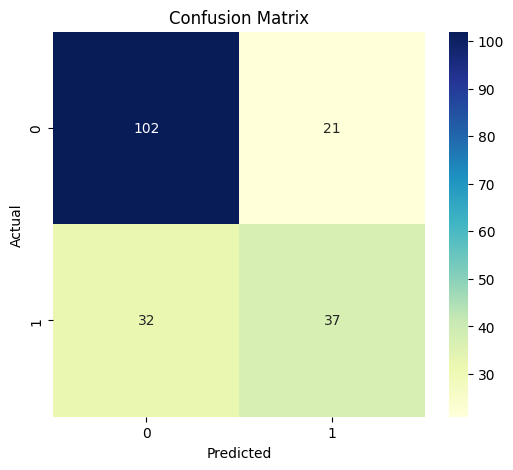

In [83]:
class_names = [0, 1]

plt.figure(figsize=(6,5))
sns.heatmap(cnf_matrix, annot=True, fmt='g', cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [84]:
y.value_counts()

Outcome
0    500
1    267
Name: count, dtype: int64

In [85]:
target_names = ['No Diabetes', 'Diabetes']

print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

 No Diabetes       0.76      0.83      0.79       123
    Diabetes       0.64      0.54      0.58        69

    accuracy                           0.72       192
   macro avg       0.70      0.68      0.69       192
weighted avg       0.72      0.72      0.72       192



In [86]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.7239583333333334


###  Key Metrics:

- **Accuracy** → Overall correctness  
- **Precision** → How many predicted diabetic are actually diabetic  
- **Recall** → How many real diabetic patients we correctly found  

👉 In healthcare, **Recall is VERY important** (don’t miss patients!)

---

##  Step 9: ROC Curve & AUC

In [87]:
y_prob = clf.predict_proba(X_test)[:, 1] #needs probablities
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
auc_score = metrics.roc_auc_score(y_test, y_prob) 

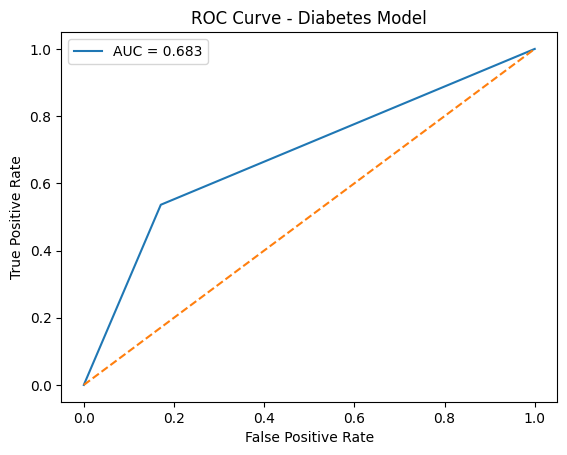

In [88]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Model")
plt.legend()

plt.show()

##  Explanation (Simple & Clear)

### 🔹 ROC Curve

**ROC = Receiver Operating Characteristic**

It shows:

- **X-axis:** False Positive Rate (wrong positives)  
- **Y-axis:** True Positive Rate (correct positives)  

 It tells how well your model separates classes.

---

### 🔹 AUC Score

**AUC = Area Under ROC Curve**

- **1.0 →** Perfect model  
- **0.5 →** Random guessing  
- **< 0.5 →** Bad model  

---

###  Interpretation Example

| AUC        | Meaning            |
|------------|-------------------|
| 0.90+      | Excellent         |
| 0.80–0.90  | Good              |
| 0.70–0.80  | Fair              |
| < 0.70     | Needs improvement |

---

###  Why ROC > Accuracy

Accuracy can mislead when:

- Data is **imbalanced** (common in medical data)

 **Example:**

- 90% non-diabetic → model predicts all “non-diabetic”  
- Accuracy = **90% ** but model is useless  

 **ROC/AUC fixes this.**

In [89]:
print("Model features:", clf.n_features_in_)
print("Your feature list:", len(feature_cols))

Model features: 8
Your feature list: 7


In [90]:
feature_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"  
]

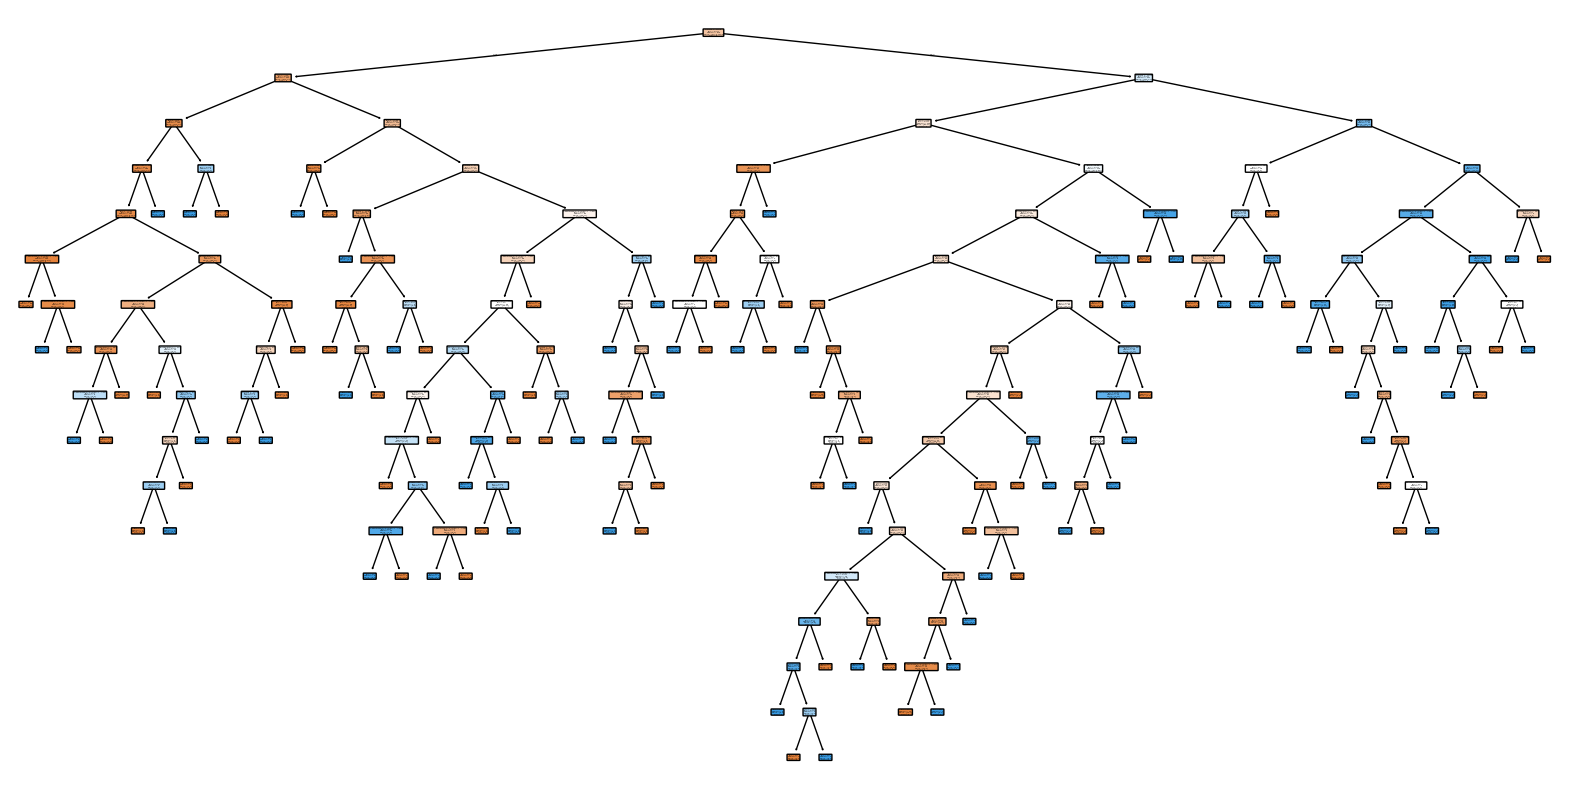

In [91]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=[str(i) for i in clf.classes_],
    filled=True,
    rounded=True
)

plt.show()